# DOWNLOADING PAPERS

**WARNING IT TAKES A LOT OF TIME!!!!!**


Using a large language model (LLM) to generate papers. Based on actual arXiv articles, the objective is to produce documents that appear authentic.

This is done to test our model's capacity to distinguish between authentic and fraudulent publications.

In [4]:
!pip install arxiv
!pip install PyMuPDF

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.5 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=52a5329c970b9b35493fccb84c1979a1207ea17c31765aaef3519603039d3299
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 43.5 MB/s eta 0:00:00


In [47]:
!pip install transformers
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.2 MB/s eta 0:00:00


**DO NOT RUN THIS, WE HAVE ALREADY DOWLOADED THE GENERATED PAPERS**

In [ ]:
import os, re, random, datetime
from pathlib import Path

import torch
import arxiv
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import ParagraphStyle, getSampleStyleSheet
from reportlab.lib.units import cm

# CONFIGURATION

out_dir = Path("fake_generated_oss")
out_dir.mkdir(parents=True, exist_ok=True) # Create output folder if it doesn't exist

NUM_PAPERS = 15                            # number of generated papers

CATEGORIES = ["cs.NI", "cs.DC", "cs.OS"]   # ArXiv categorie
WORDS_PER_SECTION = (350, 500)             # Approximate length of each section
SECTIONS = [
    "Introduction", "Related Work", "System Model", "Method",
    "Implementation", "Experimental Setup", "Results",
    "Discussion", "Threats to Validity", "Conclusion"
]
SEED = 42
random.seed(SEED)  # Ensure reproducibility

# LANGUAGE MODEL SETUP
MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"                               # Specify the LLM model to use
device = 0 if torch.cuda.is_available() else -1                               # Use GPU (0) if available, else CPU (-1)
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32   # Use half-precision on GPU, full on CPU


tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)     # Load the tokenizer for the LLM
model = AutoModelForCausalLM.from_pretrained(           # Load the causal language model
    MODEL_ID,
    torch_dtype=torch_dtype,                            # Set precision based on device
    device_map="auto" if device == 0 else None          # Automatically map model to GPU if available
)

# PIPELINE for text generation
generate = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=device,     # Automatically runs on GPU if available, otherwise CPU
)

# CLEANING text and key-words

def clean_text(s: str) -> str:
    """Normalize whitespace and trim text; safely handles None."""
    return re.sub(r"\s+", " ", (s or "").strip())

def key_terms(text, k=10):
    """Extract top-k meaningful keywords from text, ignoring stopwords and digits."""
    # Find alphanumeric tokens with at least 3 characters
    words = re.findall(r"[A-Za-z][A-Za-z0-9\-]{2,}", text.lower())

    # Manual stopwords for common/academic words
    stop = set(("a an the and or for of in on with to from as at by over under into between "
               "we our this that these those is are was were be being been can could may might "
               "using use used show shows showed obtain obtained propose proposed paper study "
               "this work").split())

    freq = {}
    for w in words:
        if w in stop or any(ch.isdigit() for ch in w):
            continue
        freq[w] = freq.get(w, 0) + 1  # Count frequency of meaningful words

    # Return top-k words, fallback to generic keywords if none
    return [w for w,_ in sorted(freq.items(), key=lambda x:-x[1])][:k] or ["system","network","protocol"]


def build_prompt(title, abstract, keywords, section_name, min_words, max_words):
    """Constructs a detailed text-generation prompt for a specific paper section."""

    kw = ", ".join(keywords)  # Join keywords into a CSV string for model guidance

    # Provide instructions to the LLM for generating coherent, technical text
    return (
        f"You are an academic writer in systems/networking.\n"
        f"Title: {title}\n"
        f"Abstract: {abstract}\n\n"
        f"Write the section: {section_name}.\n"
        f"Requirements:\n"
        f"- Length: {min_words}–{max_words} words (long paragraphs, no lists).\n"
        f"- Vary sentence structures and use connectors (However, Moreover, Consequently, In practice, etc.).\n"
        f"- Keep a coherent technical narrative; avoid repeating the same sentence template.\n"
        f"- Use domain vocabulary: {kw}.\n"
        f"Return only the prose for this section."
    )

def gen_section(title, abstract, keywords, section_name):
    """
    Generate a synthetic paper section using the LLM.
    - title: paper title (from arXiv + suffix)
    - abstract: original arXiv abstract
    - keywords: key terms extracted from abstract
    - section_name: target section (e.g., "Introduction")
    """

    lo, hi = WORDS_PER_SECTION  # Desired word range for the section

    # Build the prompt with title, abstract, section name, and keywords
    prompt = build_prompt(title, abstract, keywords, section_name, lo, hi)

    # Generate text from the model with controlled randomness
    out = generate(
        prompt,
        do_sample=True,           # Enable sampling for more varied outputs
        temperature=0.9,          # Controls creativity (higher = more diverse)
        top_p=0.92,               # Nucleus sampling: keep most probable tokens
        repetition_penalty=1.2,   # Penalize repetition of same phrases
        max_new_tokens=900,       # Allow long sections
        pad_token_id=tokenizer.eos_token_id,
    )[0]["generated_text"]

    # Keep only the generated continuation, excluding the input prompt
    text_only = out[len(prompt):]

    # Clean up formatting and return
    return clean_text(text_only)

def fetch_arxiv_abstracts(categories, max_results=300, pick=NUM_PAPERS):
    """
    Query arXiv and return a list of papers (title + abstract).
    - categories: list of arXiv categories (e.g., ["cs.NI", "cs.OS"])
    - max_results: maximum papers to fetch from API
    - pick: number of papers to return after shuffling
    """

    # Build OR query for multiple categories
    query = " OR ".join([f"cat:{c}" for c in categories])

    # Initialize client and search parameters (latest submissions first)
    cli = arxiv.Client(page_size=max_results)
    search = arxiv.Search(query=query, sort_by=arxiv.SortCriterion.SubmittedDate,
                          max_results=max_results)

    # Download results and shuffle randomly
    results = list(cli.results(search))
    random.shuffle(results)

    # Collect only title + abstract (cleaned)
    out = []
    for r in results[:pick]:
        out.append({
            "title": clean_text(r.title),
            "abstract": clean_text(r.summary or "")
        })

    return out  # Return list of dictionaries

def build_pdf(title, authors, abstract, sections_dict, out_path):
    """
    Build and save a PDF paper with title, authors, abstract, sections, and references.
    """

    # Configure PDF document (A4 size + margins)
    doc = SimpleDocTemplate(str(out_path), pagesize=A4,
                            leftMargin=2.2*cm, rightMargin=2.2*cm,
                            topMargin=2.0*cm, bottomMargin=2.0*cm)

    # Define custom text styles
    styles = getSampleStyleSheet()
    style_title  = ParagraphStyle(name="CustomTitle",  parent=styles['Heading1'], alignment=1, spaceAfter=12)
    style_meta   = ParagraphStyle(name="CustomMeta",   parent=styles['Normal'],   alignment=1, fontSize=10, spaceAfter=12)
    style_body   = ParagraphStyle(name="CustomBody",   parent=styles['Normal'],   leading=16, fontSize=11, spaceAfter=10)
    style_header = ParagraphStyle(name="CustomHeader", parent=styles['Heading2'], spaceBefore=12, spaceAfter=6)

    # Story = ordered list of elements to add in the PDF
    story = []
    story.append(Paragraph(title, style_title))   # Paper title
    story.append(Paragraph(authors, style_meta))  # Author info
    story.append(Paragraph(datetime.date.today().strftime("%B %d, %Y"), style_meta))  # Date
    story.append(Spacer(1, 6))

    # Abstract section
    story.append(Paragraph("<b>Abstract</b>", style_header))
    story.append(Paragraph(abstract, style_body))
    story.append(Spacer(1, 6))

    # Main sections (Introduction, Method, Results, etc.)
    for name, body in sections_dict.items():
        story.append(Paragraph(f"<b>{name}</b>", style_header))
        story.append(Paragraph(body, style_body))

    # References placeholder
    story.append(Paragraph("<b>References</b>", style_header))
    story.append(Paragraph("References omitted for brevity (synthetic document).", style_body))

    # Build the PDF
    doc.build(story)


# Fetch a list of real arXiv titles and abstracts
papers = fetch_arxiv_abstracts(CATEGORIES, max_results=300, pick=NUM_PAPERS)

for i, p in enumerate(papers, 1):
    abstract = p["abstract"]             # Cleaned abstract
    kws = key_terms(abstract, k=10)      # Extract top 10 keywords

    # Build synthetic paper metadata
    title = f"{p['title']} — A Systems Perspective"
    authors = "Synthetic Authors — Institute of Distributed Systems"

    # Generate all sections of the paper
    sections = {}
    for sec in SECTIONS:
        sections[sec] = gen_section(title, abstract, kws, sec)

    # Save paper as PDF
    out_pdf = out_dir / f"fake_oss_{i:02d}.pdf"
    build_pdf(title, authors, abstract, sections, out_pdf)

    print(f"[OK] {out_pdf}")             # Log completed file


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

KeyboardInterrupt: 

Download generated papers (**skip if already done** - we upload them with the next code)

In [ ]:
from google.colab import files
import shutil

folder = "fake_generated_oss"  # Folder containing the generated PDFs

# Create a ZIP file with all PDFs inside the folder
shutil.make_archive("papers", 'zip', folder)

# Download the ZIP file to the local machine
files.download("papers.zip")


FileNotFoundError: [Errno 2] No such file or directory: 'fake_generated_oss'

**Upload fake papers modified with chatgpt and those generated by us (if not downloaded above)**

In [5]:
from google.colab import files
import os

# Upload files from your local machine (multiple selection allowed)
uploaded = files.upload()

# Create a folder to store the uploaded files
os.makedirs("my_fake_docs", exist_ok=True)

# Move each uploaded file into the created folder
for fname in uploaded.keys():
    os.rename(fname, os.path.join("my_fake_docs", fname))

# Print the list of uploaded files for confirmation
print("Uploaded files:", os.listdir("my_fake_docs"))

Saving fake_oss_35.pdf to fake_oss_35.pdf
Saving fake_oss_34.pdf to fake_oss_34.pdf
Saving fake_oss_33.pdf to fake_oss_33.pdf
Saving fake_oss_32.pdf to fake_oss_32.pdf
Saving fake_oss_31.pdf to fake_oss_31.pdf
Saving fake_oss_30.pdf to fake_oss_30.pdf
Saving fake_oss_29.pdf to fake_oss_29.pdf
Saving fake_oss_28.pdf to fake_oss_28.pdf
Saving fake_oss_27.pdf to fake_oss_27.pdf
Saving fake_oss_26.pdf to fake_oss_26.pdf
Saving fake_oss_25.pdf to fake_oss_25.pdf
Saving fake_oss_24.pdf to fake_oss_24.pdf
Saving fake_oss_23.pdf to fake_oss_23.pdf
Saving fake_oss_22.pdf to fake_oss_22.pdf
Saving fake_oss_21.pdf to fake_oss_21.pdf
Saving fake_oss_20.pdf to fake_oss_20.pdf
Saving fake_oss_19.pdf to fake_oss_19.pdf
Saving fake_oss_18.pdf to fake_oss_18.pdf
Saving fake_oss_17.pdf to fake_oss_17.pdf
Saving fake_oss_16.pdf to fake_oss_16.pdf
Saving fake_oss_15.pdf to fake_oss_15.pdf
Saving fake_oss_14.pdf to fake_oss_14.pdf
Saving fake_oss_13.pdf to fake_oss_13.pdf
Saving fake_oss_12.pdf to fake_oss

**Combine the two types of paper (do not send this code if both are loaded manually)**

In [6]:
!pip install PyMuPDF python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 7.7 MB/s eta 0:00:00


Do not send this code if both are loaded manually

In [ ]:
import os, fitz, pandas as pd
from pathlib import Path
from docx import Document

# Extractor functions
def extract_text_pdf(path):
    """Extract text from a PDF file using PyMuPDF"""
    try:
        with fitz.open(path) as doc:
            # Join text from all pages
            return "\n".join(p.get_text() for p in doc), doc.page_count
    except Exception as e:
        print(f"[PDF ERROR] {path}: {e}")
        return "", None

def extract_text_docx(path):
    """Extract text from a DOCX file using python-docx"""
    try:
        doc = Document(path)
        # Join text from all paragraphs, ignoring empty ones
        return "\n".join(p.text for p in doc.paragraphs if p.text.strip())
    except Exception as e:
        print(f"[DOCX ERROR] {path}: {e}")
        return ""

# Folders to process
FOLDERS = {
    "my_fake_docs": "doc",       # User-uploaded DOC/DOCX files
    "fake_generated_oss": "pdf", # PDFs generated by LLM
}

rows = []

# Loop through each folder and file
for folder, kind in FOLDERS.items():

    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        low = fname.lower()

        text, pages = "", None
        if kind == "pdf" and low.endswith(".pdf"):
            # Extract text from PDF
            text, pages = extract_text_pdf(fpath)
        elif kind == "doc":
            if low.endswith(".docx"):
                # Extract text from DOCX
                text = extract_text_docx(fpath)
            elif low.endswith(".doc"):
                # Skip older DOC files
                print(f"[SKIP] {fname}: convert to .docx for simplicity")
                continue
        else:
            continue

        # Only keep non-empty documents
        if text.strip():
            rows.append({
                "text": text,
                "label": 0,        # All are fake
                "source": folder,  # Original folder
                "filename": fname,
                "pages": pages
            })
        else:
            print(f"[EMPTY] {fname}")

# Combine into a single DataFrame
df_fake = pd.DataFrame(rows)
before = len(df_fake)

# Remove duplicate texts
df_fake = df_fake.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"df_fake created: {len(df_fake)} rows (removed {before - len(df_fake)} duplicates)")

# Output
print(df_fake["source"].value_counts())
df_fake.head(3)

**Extract text from fake pdf**

In [7]:
import os
import fitz
import pandas as pd

In [8]:
def extract_text_from_pdf(filepath):
    """
    Extract text and page count from a single PDF file.
    Parameters:
        - filepath: full path to the PDF file
    Returns:
        - text: string containing all the text from the PDF
        - pages: number of pages in the PDF
    """
    try:
        with fitz.open(filepath) as doc:
            text = "\n".join([page.get_text() for page in doc])
            pages = doc.page_count
            return text, pages
    except Exception as e:
        print(f"Error extracting text from {filepath}: {e}")
        return "", 0  # Return empty text and 0 pages on error

In [9]:
# List to store extracted results
data = []

# Iterate only over PDF files in the folder
for fname in os.listdir("my_fake_docs"):
    if not fname.lower().endswith(".pdf"):
        continue  # Skip non-PDF files and directories

    path = os.path.join("my_fake_docs", fname)
    text, n_pages = extract_text_from_pdf(path)

    if text.strip():  # Keep only non-empty PDFs
        data.append({
            "filename": fname,
            "text": text,
            "pages": n_pages,
            "label": 0  # Mark as fake
        })
    else:
        print(f"[EMPTY] {fname}")

# Create the DataFrame
df_fake = pd.DataFrame(data)

# Preview first rows
print(df_fake.head())

          filename                                               text  pages  \
0  fake_oss_26.pdf  CoFacS -- Simulating a Complete Factory to Stu...      3   
1  fake_oss_24.pdf  FLEET: A Federated Learning Emulation and\nEva...      3   
2  fake_oss_27.pdf  MetaFed: Advancing Privacy, Performance, and\n...      2   
3  fake_oss_35.pdf  Scalable Hybrid quantum Monte Carlo simulation...      2   
4  fake_oss_02.pdf  Space-efficient population protocols for exact...      3   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


## Download true papers

In [7]:
!pip install arxiv  # Install the 'arxiv' Python library (to query and download REAL papers from arXiv.org)

In [10]:
import arxiv    # library to query and download papers from arXiv.org
import random   # for selecting random categories/papers
import shutil   # For high-level file operations
import os

In [11]:
def count_pages(path):
    """Return the number of pages in a PDF file"""
    with fitz.open(path) as doc:
        return doc.page_count

def download_true_papers(
    categories=["cs.NI","cs.DC","cs.OS"],
    true_dir="downloaded_true",
    keep_max=45,    # Keep less paper because we have less fake documents
    max_pages=25,
    pool_size=200   # number of search results to consider before sampling
):

    # Delete folder if it exists, then recreate it empty (to avoid errors)
    if os.path.isdir(true_dir):
      shutil.rmtree(true_dir)
    os.makedirs(true_dir, exist_ok=True)

    # Create a client and perform the search
    client = arxiv.Client(page_size=pool_size)                  # How many results to fetch at once
    search = arxiv.Search(
        query=" OR ".join([f"cat:{c}" for c in categories]),    # Query for multiple categories
        sort_by=arxiv.SortCriterion.SubmittedDate,              # Newest papers first
        max_results=pool_size,
    )

    # Execute the search and load results into memory
    results = list(client.results(search))
    if not results:
      print(f"No papers found for categories: {', '.join(categories)}")
      return


    random.seed(73)
    random.shuffle(results)  # shuffle results for randomness

    kept = 0
    files = []
    for r in results:
        if kept >= keep_max:
            break
        try:
            filename = f"{r.get_short_id()}.pdf"        # Generate a filename using the paper's short arXiv ID
            filepath = os.path.join(true_dir, filename) # Build the full file path where the PDF will be saved

            # Skip if already downloaded
            if os.path.exists(filepath):
                print(f"[SKIP] Already exists: {filename}")
                continue

            # Download PDF
            path = r.download_pdf(dirpath=true_dir)
            pages = count_pages(path)

            # Keep only PDFs within page limit
            if 0 < pages <= max_pages:
                files.append(path)
                kept += 1
                print(f"[OK] Kept: {os.path.basename(path)} ({pages} pages)")
            else:
                os.remove(path)
                print(f"[DROP] {os.path.basename(path)} ({pages} pages)")
        except Exception as e:
            print("Error on", getattr(r, "title", "N/A"), e)

    print(f"\nTotal kept: {len(files)}")
    return files

# Output
download_true_papers(keep_max=45)

[OK] Kept: 2509.10914v1.Deep_Learning_based_Moving_Target_Defence_for_Federated_Learning_against_Poisoning_Attack_in_MEC_Systems_with_a_6G_Wireless_Model.pdf (7 pages)
[OK] Kept: 2509.10533v1.Pair_Bid_Auction_Model_for_Optimized_Network_Slicing_in_5G_RAN.pdf (6 pages)
[OK] Kept: 2509.05675v1.Workflow_for_High_Fidelity_Dynamic_Analysis_of_Structures_with_Pile_Foundation.pdf (9 pages)
[OK] Kept: 2509.08020v1.Towards_Scalable_Proteomics__Opportunistic_SMC_Samplers_on_HTCondor.pdf (10 pages)
[OK] Kept: 2509.09291v1.What_You_Code_Is_What_We_Prove__Translating_BLE_App_Logic_into_Formal_Models_with_LLMs_for_Vulnerability_Detection.pdf (11 pages)
[OK] Kept: 2509.04084v1.LowDiff__Efficient_Frequent_Checkpointing_via_Low_Cost_Differential_for_High_Performance_Distributed_Training_Systems.pdf (16 pages)
[OK] Kept: 2509.09094v1.Coherence_Aware_Task_Graph_Modeling_for_Realistic_Application.pdf (10 pages)
[DROP] 2509.07425v1.Dependency_Aware_Execution_Mechanism_in_Hyperledger_Fabric_Architecture.pdf

['downloaded_true/2509.10914v1.Deep_Learning_based_Moving_Target_Defence_for_Federated_Learning_against_Poisoning_Attack_in_MEC_Systems_with_a_6G_Wireless_Model.pdf',
 'downloaded_true/2509.10533v1.Pair_Bid_Auction_Model_for_Optimized_Network_Slicing_in_5G_RAN.pdf',
 'downloaded_true/2509.05675v1.Workflow_for_High_Fidelity_Dynamic_Analysis_of_Structures_with_Pile_Foundation.pdf',
 'downloaded_true/2509.08020v1.Towards_Scalable_Proteomics__Opportunistic_SMC_Samplers_on_HTCondor.pdf',
 'downloaded_true/2509.09291v1.What_You_Code_Is_What_We_Prove__Translating_BLE_App_Logic_into_Formal_Models_with_LLMs_for_Vulnerability_Detection.pdf',
 'downloaded_true/2509.04084v1.LowDiff__Efficient_Frequent_Checkpointing_via_Low_Cost_Differential_for_High_Performance_Distributed_Training_Systems.pdf',
 'downloaded_true/2509.09094v1.Coherence_Aware_Task_Graph_Modeling_for_Realistic_Application.pdf',
 'downloaded_true/2509.10803v1.Enhancing_Type_Safety_in_MPI_with_Rust__A_Statically_Verified_Approach_for_

**Extract text from true pdf**

In [12]:
true_dir = "downloaded_true"

data_true = []  # list to store extracted results

for fname in os.listdir(true_dir):
    if not fname.lower().endswith(".pdf"):
        continue  # skip non-PDF files and directories

    path = os.path.join(true_dir, fname)
    text, n_pages = extract_text_from_pdf(path)  # returns text and number of pages

    if text.strip():  # keep only non-empty PDFs
        data_true.append({
            "filename": fname,
            "text": text,
            "pages": n_pages,
            "label": 1  # mark as real
        })
    else:
        print(f"[EMPTY] {fname}")

# Create the DataFrame for true papers
df_true = pd.DataFrame(data_true)

# Preview first rows
print(df_true.head())

                                            filename  \
0              2509.12223v1.Ratio1____AI_meta_OS.pdf   
1  2509.12252v1.SynergAI__Edge_to_Cloud_Synergy_f...   
2  2509.08449v1.DSFL__A_Dual_Server_Byzantine_Res...   
3  2509.08455v1.SKYLINK__Scalable_and_Resilient_L...   
4  2509.09291v1.What_You_Code_Is_What_We_Prove__T...   

                                                text  pages  label  
0  RATIO1 ∗\nAndrei Damian, Cristian Bleotiu, Pet...     21      1  
1  SynergAI: Edge-to-Cloud Synergy for Architectu...     25      1  
2  1\nDSFL: A Dual-Server Byzantine-Resilient Fed...     18      1  
3  1\nSKYLINK: Scalable and Resilient Link\nManag...     13      1  
4  JOURNAL OF LATEX CLASS FILES, VOL. 14, NO. 8, ...     11      1  


# FIRST MODEL

**Combine real and fake papers DataFrames into a single DataFrame**

In [13]:
df_combined = pd.concat([df_fake, df_true], ignore_index=True)

In [ ]:
df_combined.tail()

,filename,text,pages,label
85,2509.06766v1.Resilience_of_Mega_Satellite_Cons...,1\nResilience of Mega-Satellite Constellations...,15,1
86,2509.11636v1.Task_Agnostic_Learnable_Weighted_...,1\nTask-Agnostic Learnable Weighted-Knowledge ...,14,1
87,2509.09653v1.Towards_A_High_Performance_Quantu...,Towards A High-Performance Quantum Data Center...,6,1
88,2509.05679v1.Distributed_Deep_Learning_using_S...,Distributed Deep Learning using Stochastic Gra...,18,1
89,2509.10867v1.Agent_based_Simulation_for_Drone_...,Agent-based Simulation for Drone Charging in a...,4,1


In [ ]:
# Check number of true papers
count_label_1 = (df_combined['label'] == 1).sum()
print("Number of rows with label=1:", count_label_1)

Number of rows with label=1: 45


# **Text pre-processing**

In [14]:
import spacy
import re
import string
from nltk.corpus import stopwords
import nltk

In [15]:
# Load spaCy's English model
nlp = spacy.load("en_core_web_sm")

# Initialize NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [16]:
# Helper function for lemmatization
def lemmatize_text(tokens):
  """Lemmatize each token using spaCy's lemmatizer."""
  # Keep only alphabetic tokens and convert them to their lemma form
  lemmatized_tokens = [token.lemma_ for token in tokens if token.is_alpha]
  return " ".join(lemmatized_tokens)

In [17]:
# Define custom stopwords to exclude specific words from fake papers (with higher TF-IDF)
custom_stopwords = {"ike", "antkare", "ike antkare"}

In [18]:
# Cleaner version of the text cleaning function
def clean_text_spacy(text):
    """Clean the input text using spaCy, removing standard and custom stopwords, and lemmatizing."""

    # Convert text to lowercase
    text = text.lower()

    # Remove digits
    text = re.sub(r'\d+', '', text)

    # Remove dashes between words
    text = re.sub(r'(?<=\w)[-\u2010\u2011](?=\w)', ' ', text)

    # Remove punctuation
    text = re.sub(r'''[!"#$%&'*+,-./:;<=>?@\[\]^_\{|}~]''', "", text)

    # Tokenize the text using spaCy
    doc = nlp(text)

    # Keep only alphabetic tokens that are not in standard or custom stopwords and have length > 1
    tokens = [token for token in doc if token.is_alpha and
              token.text not in stop_words and
              token.text not in custom_stopwords and
              len(token) > 1]

    # Lemmatize the tokens
    cleaned_text = lemmatize_text(tokens)

    return cleaned_text

In [19]:
df_combined['cleaned_text'] = df_combined['text'].apply(clean_text_spacy)

In [ ]:
df_combined.head()

,filename,text,pages,label,cleaned_text
0,fake_oss_26.pdf,CoFacS -- Simulating a Complete Factory to Stu...,3,0,cofacs simulate complete factory study securit...
1,fake_oss_08.pdf,Efficient Mixed-Precision Large Language Model...,3,0,efficient mixed precision large language model...
2,fake_oss_29.pdf,CloudFormer: An Attention-based Performance\nP...,3,0,cloudformer attention base performance predict...
3,0.pdf,1 \nMulticast Frameworks No Longer Considered ...,11,0,multicast framework long consider harmful inte...
4,fake_oss_03.pdf,Beyond the Bermuda Triangle of Contention: IOM...,2,0,beyond bermuda triangle contention iommu inter...


**TEXT CLASSIFICATION**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

**TF-IDF + Linear SVM classifier**

In [21]:
X = df_combined["cleaned_text"]
y = df_combined["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Build a pipeline: TF-IDF vectorization + Linear SVM classifier
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,          # text already lowercased
        tokenizer=str.split,      # split on whitespace
        preprocessor=None,
        token_pattern=None,
        ngram_range=(1,2),        # unigrams and bigrams
        min_df=2,                 # ignore rare tokens
        max_df=0.95,              # ignore very frequent tokens
        norm="l2"
    )),
    ("clf", LinearSVC())         # fast and effective for sparse TF-IDF features
])

# Train the pipeline on the training set
pipe.fit(X_train, y_train)

# Predict on the test set
y_pred = pipe.predict(X_test)

In [22]:
# Evaluate model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15  3]
 [ 0 18]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.86      1.00      0.92        18

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.93      0.92      0.92        36



In [ ]:
# Display the distribution of labels in the training and test sets
print(y_train.value_counts())
print(y_test.value_counts())

label
1    27
0    27
Name: count, dtype: int64
label
1    18
0    18
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

AUC: 0.9814814814814814


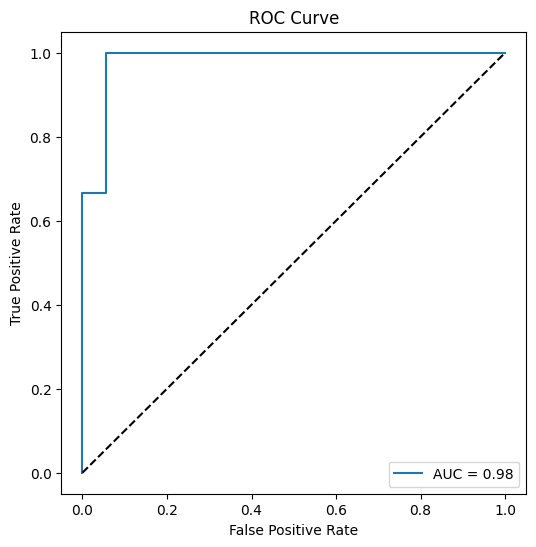

In [ ]:
# Get decision scores for test set
y_scores = pipe.decision_function(X_test)  # continuous scores

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Compute AUC
auc_score = roc_auc_score(y_test, y_scores)
print("AUC:", auc_score)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

***OTHER CLASSIFICATION MODELS***

**Logistic regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

pipe_log = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", LogisticRegression(penalty="l2", solver="liblinear", random_state=42))
])

pipe_log.fit(X_train, y_train)
y_pred = pipe_log.predict(X_test)

In [ ]:
# Evaluate LOGISTIC model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15  3]
 [ 0 18]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.86      1.00      0.92        18

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.93      0.92      0.92        36



**Naive bayes**

In [ ]:
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        tokenizer=str.split, preprocessor=None, token_pattern=None,
        analyzer="word",
        ngram_range=(1,2),
        min_df=2, max_df=0.95,
        norm="l2"
    )),
    ("clf", MultinomialNB())
])

pipe_nb.fit(X_train, y_train)
y_pred = pipe_nb.predict(X_test)

In [ ]:
# Evaluate NAIVE model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15  3]
 [ 2 16]]
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        18
           1       0.84      0.89      0.86        18

    accuracy                           0.86        36
   macro avg       0.86      0.86      0.86        36
weighted avg       0.86      0.86      0.86        36



**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred = pipe_rf.predict(X_test)

In [ ]:
# Evaluate RANDOM FOREST model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18  0]
 [ 0 18]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



**COMPARING CLASSIFIER**

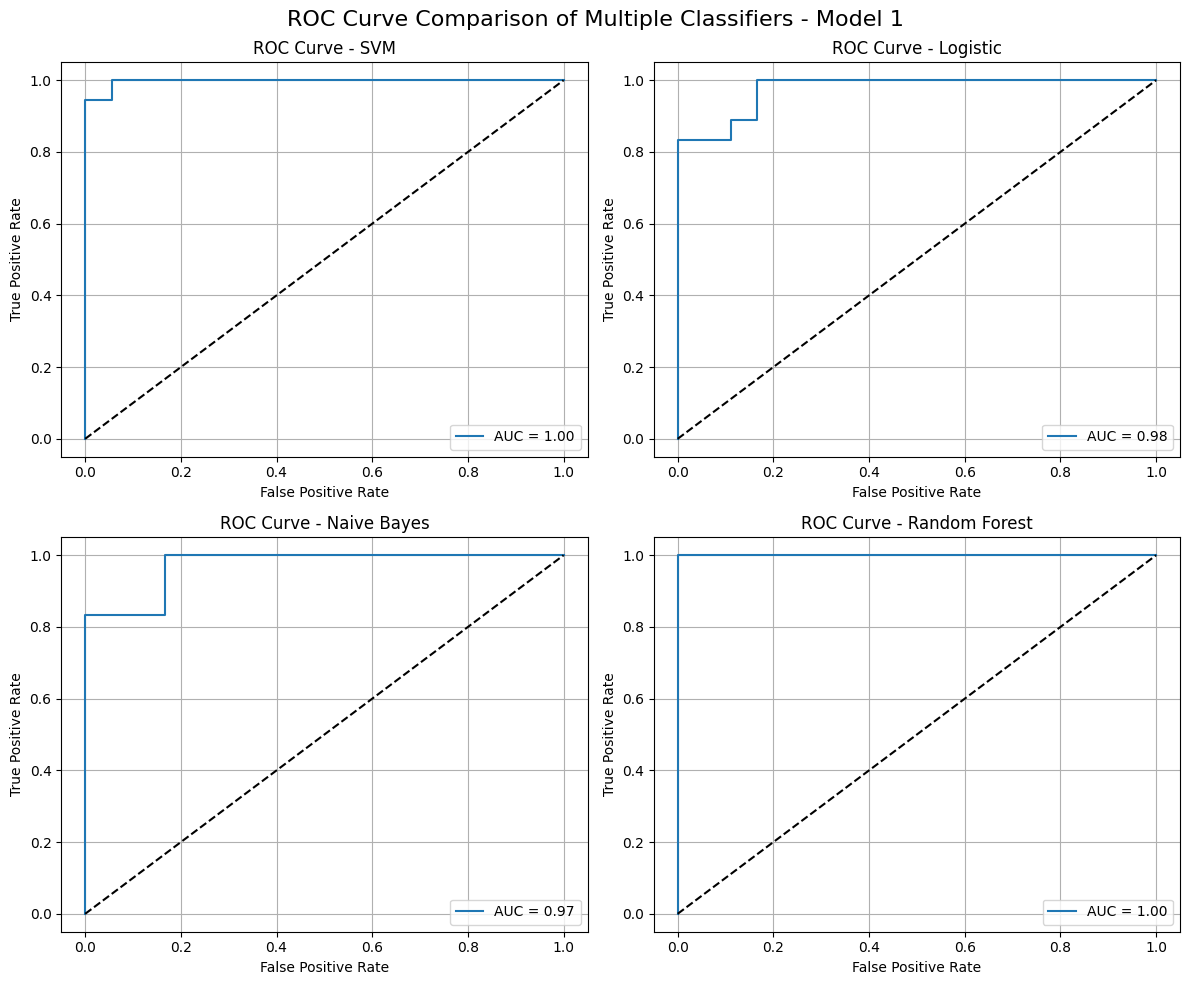

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Dictionary of trained models to compare
models = {
    "SVM": pipe,              # SVM pipeline
    "Logistic": pipe_log,     # Logistic Regression pipeline
    "Naive Bayes": pipe_nb,   # Naive Bayes pipeline
    "Random Forest": pipe_rf  # Random Forest pipeline
}

# Create side-by-side subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    # Get prediction scores
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)

    # Plot ROC curve
    ax.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    ax.plot([0, 1], [0, 1], 'k--')

    ax.set_title(f"ROC Curve - {name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True)

fig.suptitle("ROC Curve Comparison of Multiple Classifiers - Model 1", fontsize=16)
plt.tight_layout()
plt.show()

Which papers are missclassified



In [ ]:
# Train and predict with each pipeline
pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", LinearSVC())
])
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)


pipe_log = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", LogisticRegression(penalty="l2", solver="liblinear", random_state=42))
])
pipe_log.fit(X_train, y_train)
y_pred_log = pipe_log.predict(X_test)


pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        analyzer="word", ngram_range=(1,2),
        min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", MultinomialNB())
])
pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)


pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "svm_pred": y_pred_svm,
    "log_pred": y_pred_log,
    "nb_pred": y_pred_nb,
    "rf_pred": y_pred_rf,
})

# Add correctness flags
results["svm_correct"] = results["svm_pred"] == results["true"]
results["log_correct"] = results["log_pred"] == results["true"]
results["nb_correct"]  = results["nb_pred"]  == results["true"]
results["rf_correct"]  = results["rf_pred"]  == results["true"]

# See the rows where at least one model failed
misclassified = results[(~results["svm_correct"]) |
                        (~results["log_correct"]) |
                        (~results["nb_correct"]) |
                        (~results["rf_correct"])]


In [ ]:
all_failed = misclassified[
    (~misclassified["svm_correct"]) &
    (~misclassified["log_correct"]) &
    (~misclassified["nb_correct"]) &
    (~misclassified["rf_correct"])
]


In [ ]:
# Build results DataFrame with filenames
results = pd.DataFrame({
    "filename": X_test.index.map(df_combined["filename"]),  # map test indices back to filenames
    "true": y_test,
    "svm_pred": y_pred_svm,
    "log_pred": y_pred_log,
    "nb_pred": y_pred_nb,
    "rf_pred": y_pred_rf
})

# Add correctness flags
results["svm_correct"] = results["svm_pred"] == results["true"]
results["log_correct"] = results["log_pred"] == results["true"]
results["nb_correct"]  = results["nb_pred"]  == results["true"]
results["rf_correct"]  = results["rf_pred"]  == results["true"]

# Show filenames where each model failed
svm_failed = results.loc[~results["svm_correct"], ["filename", "true", "svm_pred"]]
log_failed = results.loc[~results["log_correct"], ["filename", "true", "log_pred"]]
nb_failed  = results.loc[~results["nb_correct"],  ["filename", "true", "nb_pred"]]
rf_failed  = results.loc[~results["rf_correct"],  ["filename", "true", "rf_pred"]]

print("SVM failed on:\n", svm_failed)
print("Logistic failed on:\n", log_failed)
print("Naive Bayes failed on:\n", nb_failed)
print("Random Forest failed on:\n", rf_failed)


SVM failed on:
            filename  true  svm_pred
11  fake_oss_18.pdf     0         1
10  fake_oss_10.pdf     0         1
7   fake_oss_33.pdf     0         1
Logistic failed on:
            filename  true  log_pred
11  fake_oss_18.pdf     0         1
10  fake_oss_10.pdf     0         1
7   fake_oss_33.pdf     0         1
Naive Bayes failed on:
                                              filename  true  nb_pred
11                                    fake_oss_18.pdf     0        1
62  2509.05675v1.Workflow_for_High_Fidelity_Dynami...     1        0
10                                    fake_oss_10.pdf     0        1
7                                     fake_oss_33.pdf     0        1
70  2509.09094v1.Coherence_Aware_Task_Graph_Modeli...     1        0
Random Forest failed on:
 Empty DataFrame
Columns: [filename, true, rf_pred]
Index: []


In [ ]:
df_combined.head()

,filename,text,pages,label,cleaned_text
0,fake_oss_10.pdf,FedUHD: Unsupervised Federated Learning using\...,3,0,feduhd unsupervised federate learning use hype...
1,6.pdf,1 \n \n \n \nThe Relationship Between Wide-Are...,15,0,relationship wide area network memory bus inte...
2,fake_oss_16.pdf,CoFacS -- Simulating a Complete Factory to Stu...,2,0,cofacs simulate complete factory study securit...
3,fake_oss_14.pdf,Collaborative Evolution of Intelligent Agents ...,3,0,collaborative evolution intelligent agent larg...
4,fake_oss_02.pdf,Space-efficient population protocols for exact...,3,0,space efficient population protocol exact majo...


#N-grams

In [25]:
# Search for fixed sentence structures --> N-GRAM
X = df_combined["cleaned_text"].astype(str)
y = df_combined["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,           # Do not lowercase text
        tokenizer=str.split,       # Split on spaces
        preprocessor=None,
        token_pattern=None,
        analyzer="word",
        ngram_range=(2,5),         # Consider 2 to 5 N-grams
        min_df=2, max_df=0.95,     # Ignore rare and very frequent terms
        norm="l2"                  # L2 normalization
    )),
    ("clf", LinearSVC())           # Linear SVM classifier
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

In [26]:
# Extract trained TF-IDF vectorizer and classifier
vec = pipe.named_steps["tfidf"]
clf = pipe.named_steps["clf"]
feature_names = np.array(vec.get_feature_names_out())

# Get class order and coefficients
classes = clf.classes_
coefs = clf.coef_[0]

# Order features by weight
order_pos = np.argsort(coefs)[::-1]  # Top positive weights (favor real)
order_neg = np.argsort(coefs)        # Top negative weights (favor fake)

top_k = 15
# Top n-grams for real class
top_real = pd.DataFrame({
    "ngram": feature_names[order_pos][:top_k],
    "weight": coefs[order_pos][:top_k]
})

# Top n-grams for fake class
top_fake = pd.DataFrame({
    "ngram": feature_names[order_neg][:top_k],
    "weight": coefs[order_neg][:top_k]
})

# Display results
print("TOP n-grams for REAL (label=1)")
display(top_real)

print("\n TOP n-grams for FAKE (label=0)")
display(top_fake)

TOP n-grams for REAL (label=1)


,ngram,weight
0,et al,0.467073
1,vol pp,0.447904
2,batch size,0.353157
3,online available,0.316916
4,bad case,0.286687
5,smart contract,0.286330
6,step size,0.284732
7,formal specification,0.245368
8,large batch,0.242016
9,top top,0.230980



 TOP n-grams for FAKE (label=0)


,ngram,weight
0,mixed precision,-0.366800
1,holo artisan,-0.342372
2,threat validity,-0.284088
3,system perspective,-0.278062
4,reference reference omit brevity,-0.242812
5,distribute system september abstract,-0.242812
6,synthetic author institute distribute system,-0.242812
7,synthetic document,-0.242812
8,institute distribute system,-0.242812
9,institute distribute system september,-0.242812


In [ ]:
# Evaluate model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18  0]
 [ 0 18]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



**SHAP**

In [37]:
import shap
import matplotlib.pyplot as plt

In [38]:
# Transform the test set with TF-IDF
X_test_tfidf = pipe.named_steps["tfidf"].transform(X_test)
X_test_dense = X_test_tfidf.toarray()  # required for SHAP

feature_names = pipe.named_steps["tfidf"].get_feature_names_out()
clf = pipe.named_steps["clf"]

# SHAP explainer for LinearSVC
explainer = shap.LinearExplainer(clf, X_test_dense, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_dense)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


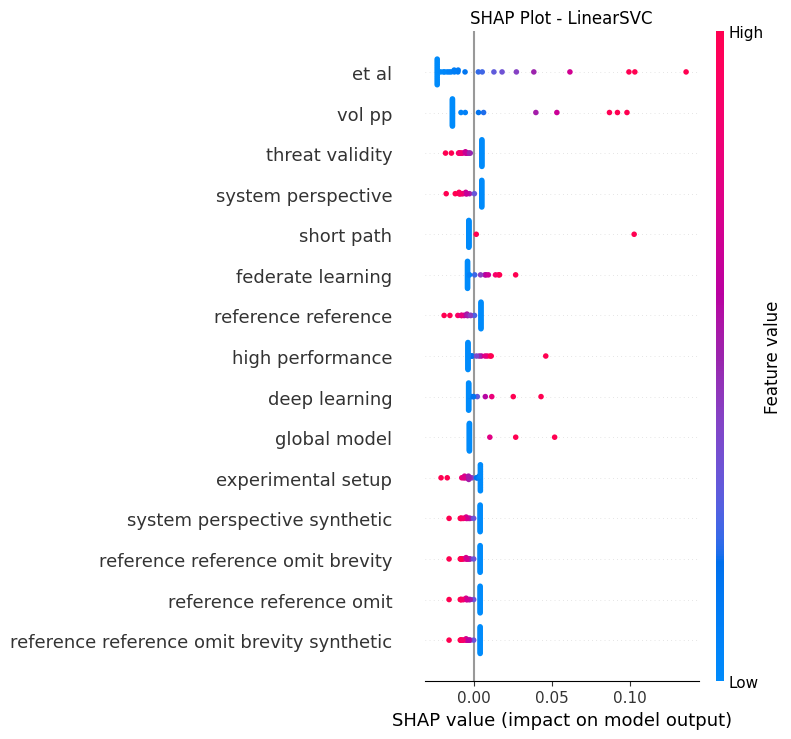

In [45]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names,
    show=False,
    max_display=15
)
plt.title("SHAP Plot - LinearSVC")
plt.tight_layout()
plt.show()

#**Second model** - add noise to true papers

In this model, we will use:
-   Papers previously generated with LLM
-   Fake papers from Scigen that we have tampered with using ChatGPT
-   Real papers downloaded earlier but which will be noised
- New real papers that will be used to see how our modal can distinguish the two classes: fake(0) and real(1)

**All the documents have been downloaded already, so let's move straight on to noising real papers.**

In [48]:
import random, re, datetime
from pathlib import Path
import fitz
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from xml.sax.saxutils import escape

In [49]:
# CONFIGURATION

IN_DIR  = Path("downloaded_true")           # Directory containing real PDF papers
OUT_DIR = Path("noisy_true_pdf")            # Directory where noisy PDFs will be saved
OUT_DIR.mkdir(parents=True, exist_ok=True)  # Ensure output folder exists

random.seed(73)  # Set seed for reproducibility

NOISE_LEVEL = 4  # Noise intensity: 1 (low) to 5 (high)

# Extract full text and number of pages from a PDF using PyMuPDF
def read_pdf_text(path):
    with fitz.open(path) as doc:
        text = "\n".join(page.get_text() for page in doc)
        pages = doc.page_count
    return text, pages

def split_sections(text):
    """
    Simple section splitter based on common headings.
    Returns a list of tuples (section_title, section_content).
    """
    heads = [
        r"abstract", r"introduction", r"related work", r"background",
        r"system model", r"method", r"methods", r"approach",
        r"implementation", r"experimental setup", r"experiments",
        r"results", r"evaluation", r"discussion",
        r"threats to validity", r"limitations",
        r"conclusion", r"conclusions", r"future work",
        r"references"
    ]
    pat = re.compile(rf"^\s*({'|'.join(heads)})\s*$", re.I | re.M)

    blocks = []
    last = 0
    last_name = "preamble"
    for m in pat.finditer(text):
        blk = text[last:m.start()].strip()
        if blk:
            blocks.append((last_name, blk))
        last_name = m.group(1).strip()
        last = m.end()

    tail = text[last:].strip()
    if tail:
        blocks.append((last_name, tail))

    return blocks if blocks else [("body", text)]

# Text tokenization
def sent_tokenize(block):
    parts = re.split(r'(?<=[\.\?\!;])\s+', block.strip())
    return [s.strip() for s in parts if s.strip()]

# Minimal synonym dictionary for soft paraphrasing
SYN = {
    "demonstrates":"shows", "reveals":"indicates", "suggests":"implies",
    "propose":"present", "proposes":"presents", "method":"approach",
    "methods":"approaches", "framework":"architecture",
    "efficient":"scalable", "robust":"reliable", "evaluation":"assessment",
    "results":"findings", "improvement":"benefit", "throughput":"capacity",
    "latency":"delay", "network":"system", "distributed":"decentralized",
    "consensus":"agreement", "scheduling":"orchestration"
}

BUZZ = [
    "distributed consensus", "fault tolerance", "container orchestration",
    "load balancing", "virtual machine migration", "network slicing",
    "stream processing", "checkpointing", "service discovery",
    "data replication", "latency optimization", "message-passing interface"
]

CONNECTORS = ["However,","Moreover,","Consequently,","In practice,","Therefore,","Notably,"]

# Replace words with synonyms with a certain probability
def soft_synonymize(text, prob=0.05):
    def repl(m):
        w = m.group(0)
        if random.random() < prob:
            lw = w.lower()
            if lw in SYN:
                rep = SYN[lw]
                return rep.capitalize() if w[0].isupper() else rep
        return w
    return re.sub(r"\b[A-Za-z][A-Za-z\-]{2,}\b", repl, text)

# Randomly modify numbers in the text by a small percentage
def alter_numbers(text, prob=0.1, delta=(0.05, 0.15)):
    def repl(m):
        if random.random() < prob:
            val = float(m.group(0))
            sign = -1 if random.random() < 0.5 else 1
            pct = random.uniform(*delta)
            new = val * (1 + sign * pct)
            if m.group(0).isdigit():
                return str(int(round(new)))
            return f"{new:.2f}"
        return m.group(0)
    return re.sub(r"\b\d+(?:\.\d+)?\b", repl, text)

# Generate a fake academic sentence with a buzzword
def insert_buzz_sentence(keywords):
    k = random.choice(keywords or ["systems"])
    b = random.choice(BUZZ)
    c = random.choice(CONNECTORS)
    return f"{c} our findings suggest that {k} benefits from {b} under realistic workload conditions."

# Generate fake references for a references section
def corrupt_references(block):
    lines = [l.strip() for l in block.splitlines() if l.strip()]
    out = []
    for i, l in enumerate(lines[:max(5, len(lines)//2)], 1):
        year = random.randint(2008, 2024)
        venue = random.choice(["OSDI","SOSP","NSDI","SIGCOMM","EuroSys","ICDL","USENIX ATC"])
        fake_title = f"On Scalable {random.choice(['Consensus','Scheduling','Replication','Telemetry'])} for Large-Scale Systems"
        out.append(f"[{i}] Doe, J.; Roe, R. \"{fake_title}.\" {venue}, {year}.")
    return "\n".join(out)

# Apply noise to sections
def remix_section(name, text, level=3, keywords=None):
    sents = sent_tokenize(text)

    # Noise probabilities proportional to level
    p_shuffle = 0.05 * level
    p_drop    = 0.03 * level
    p_dup     = 0.02 * level
    p_syn     = 0.04 * level
    p_nums    = 0.04 * level
    p_inject  = 0.02 * level

    # Partial shuffle
    if random.random() < p_shuffle:
        random.shuffle(sents)

    # Drop or duplicate sentences
    new_sents = []
    for s in sents:
        if random.random() < p_drop:
            continue
        new_sents.append(s)
        if random.random() < p_dup:
            new_sents.append(s)

    # Inject buzz sentence
    if random.random() < p_inject:
        new_sents.insert(random.randrange(len(new_sents)+1), insert_buzz_sentence(keywords or []))

    # Recombine and apply synonyms and number alterations
    out = " ".join(new_sents)
    out = soft_synonymize(out, prob=p_syn)
    out = alter_numbers(out, prob=p_nums)

    # Corrupt references section if applicable
    if re.fullmatch(r"references?", name, re.I):
        out = corrupt_references(out)
    return out

def reorder_sections(sections, level=3):
    """Slightly reorder internal sections, keeping abstract and references fixed."""
    fixed_first = []
    fixed_last  = []
    middle = []
    for n, t in sections:
        if re.fullmatch(r"abstract", n, re.I):
            fixed_first.append((n,t))
        elif re.fullmatch(r"references?", n, re.I):
            fixed_last.append((n,t))
        else:
            middle.append((n,t))
    # Small permutation
    swaps = min(level, max(0, len(middle)-1))
    for _ in range(swaps):
        i, j = random.sample(range(len(middle)), 2)
        middle[i], middle[j] = middle[j], middle[i]
    return fixed_first + middle + fixed_last

# PDF GENERATION

def build_pdf(title, body_text, out_path):
    """Create a PDF with the given title and body text"""
    doc = SimpleDocTemplate(str(out_path), pagesize=A4,
                            leftMargin=2.2*cm, rightMargin=2.2*cm,
                            topMargin=2.0*cm, bottomMargin=2.0*cm)
    styles = getSampleStyleSheet()
    st_title  = ParagraphStyle(name="CustomTitle",  parent=styles['Heading1'], alignment=1, spaceAfter=12)
    st_body   = ParagraphStyle(name="CustomBody",   parent=styles['Normal'],   leading=16, fontSize=11, spaceAfter=10)
    st_header = ParagraphStyle(name="CustomHeader", parent=styles['Heading2'], spaceBefore=12, spaceAfter=6)

    story = []
    story.append(Paragraph(escape(title), st_title))
    story.append(Paragraph(datetime.date.today().strftime("%B %d, %Y"), st_body))
    story.append(Spacer(1, 8))

    # Split into paragraphs
    for para in body_text.split("\n\n"):
        p = para.strip()
        if not p:
            continue
        if len(p) < 60:
            story.append(Paragraph(f"<b>{escape(p)}</b>", st_header))
        else:
            story.append(Paragraph(escape(p), st_body))
    doc.build(story)


# MAIN LOOP: process all PDFs -> create noisy versions

# Collect all PDF files in the input directory
pdfs = [p for p in IN_DIR.glob("*.pdf")]
print(f"Found {len(pdfs)} real PDFs in {IN_DIR}")

# Process each PDF one by one
for idx, pdf in enumerate(pdfs, 1):

    # 1) Extract full text and number of pages
    raw_text, pages = read_pdf_text(pdf)
    if not raw_text.strip():
        print(f"[SKIP] Empty or unreadable: {pdf.name}")
        continue

    # 2) Split the text into sections using common headings
    sections = split_sections(raw_text)

    # 3) Lightly reorder sections (abstract and references stay at the ends)
    sections = reorder_sections(sections, level=NOISE_LEVEL)

    # 4) Prepare a title and extract keywords for noise injection
    title = f"{pdf.stem} — Modified Version"
    keywords = re.findall(r"[A-Za-z][A-Za-z\-]{3,}", raw_text.lower())
    keywords = list({w for w in keywords if w not in {'the','and','for','with','this','that','from','into','onto'}})[:10]

    # 5) Apply noise and remix each section
    remixed_blocks = []
    for name, content in sections:
        name_clean = name.strip().title()                 # Capitalize section heading
        body = remix_section(name, content, level=NOISE_LEVEL, keywords=keywords)
        remixed_blocks.append(name_clean)                 # Add section heading
        remixed_blocks.append(body)                       # Add noisy content
        remixed_blocks.append("")                         # Add empty line for spacing

    final_text = "\n\n".join(remixed_blocks)              # Combine all blocks into a single text

    # 6) Save the modified PDF to the output directory
    out_pdf = OUT_DIR / f"{pdf.stem}_noisy.pdf"
    build_pdf(title, final_text, out_pdf)

    print(f"[OK] {idx}/{len(pdfs)} -> {out_pdf}")


Found 45 real PDFs in downloaded_true
[OK] 1/45 -> noisy_true_pdf/2509.12223v1.Ratio1____AI_meta_OS_noisy.pdf
[OK] 2/45 -> noisy_true_pdf/2509.12252v1.SynergAI__Edge_to_Cloud_Synergy_for_Architecture_Driven_High_Performance_Orchestration_for_AI_Inference_noisy.pdf
[OK] 3/45 -> noisy_true_pdf/2509.08449v1.DSFL__A_Dual_Server_Byzantine_Resilient_Federated_Learning_Framework_via_Group_Based_Secure_Aggregation_noisy.pdf
[OK] 4/45 -> noisy_true_pdf/2509.08455v1.SKYLINK__Scalable_and_Resilient_Link_Management_in_LEO_Satellite_Network_noisy.pdf
[OK] 5/45 -> noisy_true_pdf/2509.09291v1.What_You_Code_Is_What_We_Prove__Translating_BLE_App_Logic_into_Formal_Models_with_LLMs_for_Vulnerability_Detection_noisy.pdf
[OK] 6/45 -> noisy_true_pdf/2509.08020v1.Towards_Scalable_Proteomics__Opportunistic_SMC_Samplers_on_HTCondor_noisy.pdf
[OK] 7/45 -> noisy_true_pdf/2509.07410v1.TEGRA__A_Flexible___Scalable_NextGen_Mobile_Core_noisy.pdf
[OK] 8/45 -> noisy_true_pdf/2509.12222v1.Accelerating_Privacy_Preservin

**Dataframe fake updated with noisy ture data**

In [50]:
from pathlib import Path
import os, fitz, pandas as pd

# Load only the noisy PDFs
rows_noisy = []
noisy_dir = "noisy_true_pdf"

for fname in os.listdir(noisy_dir):
    if not fname.lower().endswith(".pdf"):
        continue
    path = os.path.join(noisy_dir, fname)
    text, pages = extract_text_from_pdf(path)
    if text.strip():
        rows_noisy.append({
            "filename": fname,
            "text": text,
            "pages": pages,
            "label": 0,             # all are fake
            "source": "noisy_true_pdf"
        })
    else:
        print(f"[EMPTY] {fname}")

df_noisy = pd.DataFrame(rows_noisy)

# Merge with the existing df_fake
df_fake = pd.concat([df_fake, df_noisy], ignore_index=True)

# Optional: remove duplicates based on text content to avoid problems
df_fake = df_fake.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"df_fake updated: {len(df_fake)} rows")
print(df_fake["source"].value_counts())

df_fake updated: 90 rows
source
noisy_true_pdf    45
Name: count, dtype: int64


In [ ]:
df_fake.head()

,filename,text,pages,label,source
0,fake_oss_26.pdf,CoFacS -- Simulating a Complete Factory to Stu...,3,0,NaN
1,fake_oss_08.pdf,Efficient Mixed-Precision Large Language Model...,3,0,NaN
2,fake_oss_29.pdf,CloudFormer: An Attention-based Performance\nP...,3,0,NaN
3,0.pdf,1 \nMulticast Frameworks No Longer Considered ...,11,0,NaN
4,fake_oss_03.pdf,Beyond the Bermuda Triangle of Contention: IOM...,2,0,NaN


Remove true papers from the earlier folder to upload new real documents

In [51]:
import shutil, os

true_dir = "downloaded_true"
if os.path.isdir(true_dir):
    shutil.rmtree(true_dir)     # delete the whole folder
os.makedirs(true_dir, exist_ok=True)

Download the real papers that will be compared with our "new" fake papers

In [52]:
def count_pages(path):
    """Return the number of pages in a PDF file"""
    with fitz.open(path) as doc:
        return doc.page_count

def download_true_papers(
    categories=["cs.NI","cs.DC","cs.OS"],
    true_dir="downloaded_true",
    keep_max=90,
    max_pages=25,
    pool_size=200   # number of search results to consider before sampling
):

    # Delete folder if it exists, then recreate it empty (to avoid errors)
    if os.path.isdir(true_dir):
      shutil.rmtree(true_dir)
    os.makedirs(true_dir, exist_ok=True)

    # Create a client and perform the search
    client = arxiv.Client(page_size=pool_size)                  # How many results to fetch at once
    search = arxiv.Search(
        query=" OR ".join([f"cat:{c}" for c in categories]),    # Query for multiple categories
        sort_by=arxiv.SortCriterion.SubmittedDate,              # Newest papers first
        max_results=pool_size,
    )

    # Execute the search and load results into memory
    results = list(client.results(search))
    if not results:
      print(f"No papers found for categories: {', '.join(categories)}")
      return

    random.seed(73)
    random.shuffle(results)  # shuffle results for randomness

    kept = 0
    files = []
    for r in results:
        if kept >= keep_max:
            break
        try:
            filename = f"{r.get_short_id()}.pdf"        # Generate a filename using the paper's short arXiv ID
            filepath = os.path.join(true_dir, filename) # Build the full file path where the PDF will be saved

            # Skip if already downloaded
            if os.path.exists(filepath):
                print(f"[SKIP] Already exists: {filename}")
                continue

            # Download PDF
            path = r.download_pdf(dirpath=true_dir)
            pages = count_pages(path)

            # Keep only PDFs within page limit
            if 0 < pages <= max_pages:
                files.append(path)
                kept += 1
                print(f"[OK] Kept: {os.path.basename(path)} ({pages} pages)")
            else:
                os.remove(path)
                print(f"[DROP] {os.path.basename(path)} ({pages} pages)")
        except Exception as e:
            print("Error on", getattr(r, "title", "N/A"), e)

    print(f"\nTotal kept: {len(files)}")
    return files

# Output
download_true_papers(keep_max=90)

[OK] Kept: 2509.10914v1.Deep_Learning_based_Moving_Target_Defence_for_Federated_Learning_against_Poisoning_Attack_in_MEC_Systems_with_a_6G_Wireless_Model.pdf (7 pages)
[OK] Kept: 2509.10533v1.Pair_Bid_Auction_Model_for_Optimized_Network_Slicing_in_5G_RAN.pdf (6 pages)
[OK] Kept: 2509.05675v1.Workflow_for_High_Fidelity_Dynamic_Analysis_of_Structures_with_Pile_Foundation.pdf (9 pages)
[OK] Kept: 2509.08020v1.Towards_Scalable_Proteomics__Opportunistic_SMC_Samplers_on_HTCondor.pdf (10 pages)
[OK] Kept: 2509.09291v1.What_You_Code_Is_What_We_Prove__Translating_BLE_App_Logic_into_Formal_Models_with_LLMs_for_Vulnerability_Detection.pdf (11 pages)
[OK] Kept: 2509.04084v1.LowDiff__Efficient_Frequent_Checkpointing_via_Low_Cost_Differential_for_High_Performance_Distributed_Training_Systems.pdf (16 pages)
[OK] Kept: 2509.09094v1.Coherence_Aware_Task_Graph_Modeling_for_Realistic_Application.pdf (10 pages)
[DROP] 2509.07425v1.Dependency_Aware_Execution_Mechanism_in_Hyperledger_Fabric_Architecture.pdf

['downloaded_true/2509.10914v1.Deep_Learning_based_Moving_Target_Defence_for_Federated_Learning_against_Poisoning_Attack_in_MEC_Systems_with_a_6G_Wireless_Model.pdf',
 'downloaded_true/2509.10533v1.Pair_Bid_Auction_Model_for_Optimized_Network_Slicing_in_5G_RAN.pdf',
 'downloaded_true/2509.05675v1.Workflow_for_High_Fidelity_Dynamic_Analysis_of_Structures_with_Pile_Foundation.pdf',
 'downloaded_true/2509.08020v1.Towards_Scalable_Proteomics__Opportunistic_SMC_Samplers_on_HTCondor.pdf',
 'downloaded_true/2509.09291v1.What_You_Code_Is_What_We_Prove__Translating_BLE_App_Logic_into_Formal_Models_with_LLMs_for_Vulnerability_Detection.pdf',
 'downloaded_true/2509.04084v1.LowDiff__Efficient_Frequent_Checkpointing_via_Low_Cost_Differential_for_High_Performance_Distributed_Training_Systems.pdf',
 'downloaded_true/2509.09094v1.Coherence_Aware_Task_Graph_Modeling_for_Realistic_Application.pdf',
 'downloaded_true/2509.10803v1.Enhancing_Type_Safety_in_MPI_with_Rust__A_Statically_Verified_Approach_for_

**Extract test from true pdf**

In [53]:
import fitz  # PyMuPDF so you cxan work with pdf
import pandas as pd

In [54]:
true_dir = "downloaded_true"

data_true = []  # list to store extracted results

for fname in os.listdir(true_dir):
    if not fname.lower().endswith(".pdf"):
        continue  # skip non-PDF files and directories

    path = os.path.join(true_dir, fname)
    text, n_pages = extract_text_from_pdf(path)  # returns text and number of pages

    if text.strip():  # keep only non-empty PDFs
        data_true.append({
            "filename": fname,
            "text": text,
            "pages": n_pages,
            "label": 1  # mark as real
        })
    else:
        print(f"[EMPTY] {fname}")

# Create the DataFrame for true papers
df_true = pd.DataFrame(data_true)

# Preview first rows
print(df_true.head())

                                            filename  \
0              2509.12223v1.Ratio1____AI_meta_OS.pdf   
1  2509.10251v1.XBOF__A_Cost_Efficient_CXL_JBOF_w...   
2  2509.06064v1.Gathering_in_Non_Vertex_Transitiv...   
3  2509.06229v1.20_Years_in_Life_of_a_Smart_Build...   
4  2509.07727v1.MoE_Compression__How_the_Compress...   

                                                text  pages  label  
0  RATIO1 ∗\nAndrei Damian, Cristian Bleotiu, Pet...     21      1  
1  XBOF: A Cost-Efficient CXL JBOF with Inter-SSD...     15      1  
2  Gathering in Non-Vertex-Transitive Graphs Unde...     16      1  
3  20 Years in Life of a Smart Building: A retros...      7      1  
4  MoE-Compression: How the Compression Error of ...     10      1  


**Combine real and fake papers DataFrames into a single DataFrame**

In [55]:
df_combined = pd.concat([df_true, df_fake], ignore_index=True)

**Data pre-processing**

In [56]:
import spacy
import re
import string
from nltk.corpus import stopwords
import re

# Load spaCy's English model
nlp = spacy.load("en_core_web_sm")

# Initialize stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [57]:
# Helper function for lemmatization
def lemmatize_text(tokens):
    """Lemmatize each token using spaCy's lemmatizer."""
    lemmatized_tokens = [token.lemma_ for token in tokens if token.is_alpha]
    return " ".join(lemmatized_tokens)

In [58]:
# Cleaner version of the text cleaning function
def clean_text_spacy(text):
    """Clean the input text using spaCy, removing standard and custom stopwords, and lemmatizing."""

    # Convert text to lowercase
    text = text.lower()

    # Remove digits
    text = re.sub(r'\d+', '', text)

    # Remove dashes between words
    text = re.sub(r'(?<=\w)[-\u2010\u2011](?=\w)', ' ', text)

    # Remove punctuation
    text = re.sub(r'''[!"#$%&'*+,-./:;<=>?@\[\]^_\{|}~]''', "", text)

    # Tokenize the text using spaCy
    doc = nlp(text)

    # Keep only alphabetic tokens that are not in standard or custom stopwords and have length > 1
    tokens = [token for token in doc if token.is_alpha and
              token.text not in stop_words and
              token.text not in custom_stopwords and
              len(token) > 1]

    # Lemmatize the tokens
    cleaned_text2 = lemmatize_text(tokens)

    return cleaned_text2

In [59]:
df_combined['cleaned_text2'] = df_combined['text'].apply(clean_text_spacy)

**TEXT CLASSIFICATION**

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [61]:
X = df_combined["cleaned_text2"]
y = df_combined["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Build a pipeline: TF-IDF vectorization + Linear SVM classifier
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,          # text already lowercased
        tokenizer=str.split,      # split on whitespace
        preprocessor=None,
        token_pattern=None,
        ngram_range=(1,2),        # unigrams and bigrams
        min_df=2,                 # ignore rare tokens
        max_df=0.95,              # ignore very frequent tokens
        norm="l2"
    )),
    ("clf", LinearSVC())         # fast and effective for sparse TF-IDF features
])

# Train the pipeline on the training set
pipe.fit(X_train, y_train)

# Predict on the test set
y_pred = pipe.predict(X_test)

In [48]:
# Evaluate model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[31  5]
 [ 3 33]]
              precision    recall  f1-score   support

           0       0.91      0.86      0.89        36
           1       0.87      0.92      0.89        36

    accuracy                           0.89        72
   macro avg       0.89      0.89      0.89        72
weighted avg       0.89      0.89      0.89        72



**ROC curve - AUC**

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

AUC: 0.9953703703703705


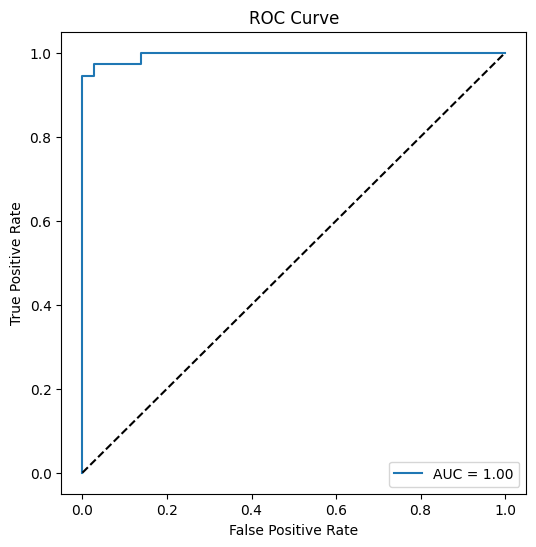

In [ ]:
# Get decision scores for test set
y_scores = pipe.decision_function(X_test)  # continuous scores

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Compute AUC
auc_score = roc_auc_score(y_test, y_scores)
print("AUC:", auc_score)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

***OTHER CLASSIFICATION MODELS***

**Logistic regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

pipe_log = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", LogisticRegression(penalty="l2", solver="liblinear", random_state=42))
])

pipe_log.fit(X_train, y_train)
y_pred = pipe_log.predict(X_test)

In [ ]:
# Evaluate LOGISTIC model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[29  7]
 [ 2 34]]
              precision    recall  f1-score   support

           0       0.94      0.81      0.87        36
           1       0.83      0.94      0.88        36

    accuracy                           0.88        72
   macro avg       0.88      0.88      0.87        72
weighted avg       0.88      0.88      0.87        72



**Naive bayes**

In [ ]:
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        tokenizer=str.split, preprocessor=None, token_pattern=None,
        analyzer="word",
        ngram_range=(1,2),
        min_df=2, max_df=0.95,
        norm="l2"
    )),
    ("clf", MultinomialNB())
])

pipe_nb.fit(X_train, y_train)
y_pred = pipe_nb.predict(X_test)

In [ ]:
# Evaluate NAIVE model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[31  5]
 [ 9 27]]
              precision    recall  f1-score   support

           0       0.78      0.86      0.82        36
           1       0.84      0.75      0.79        36

    accuracy                           0.81        72
   macro avg       0.81      0.81      0.80        72
weighted avg       0.81      0.81      0.80        72



**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred = pipe_rf.predict(X_test)

In [ ]:
# Evaluate RANDOM FOREST model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[34  2]
 [ 1 35]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.96        36
           1       0.95      0.97      0.96        36

    accuracy                           0.96        72
   macro avg       0.96      0.96      0.96        72
weighted avg       0.96      0.96      0.96        72



**COMPARING CLASSIFIER**

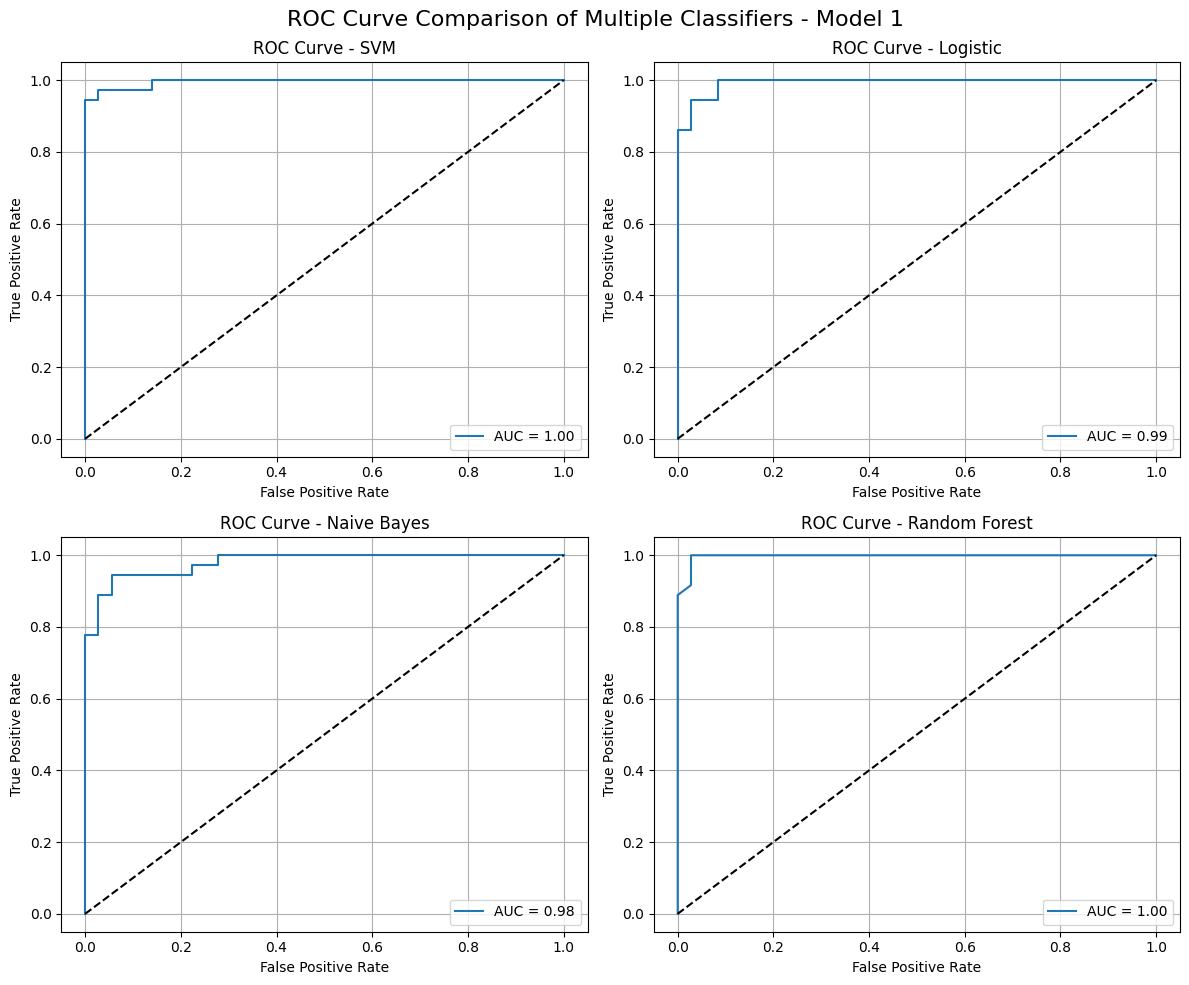

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Dictionary of trained models to compare
models = {
    "SVM": pipe,              # SVM pipeline
    "Logistic": pipe_log,     # Logistic Regression pipeline
    "Naive Bayes": pipe_nb,   # Naive Bayes pipeline
    "Random Forest": pipe_rf  # Random Forest pipeline
}

# Create side-by-side subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    # Get prediction scores
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)

    # Plot ROC curve
    ax.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    ax.plot([0, 1], [0, 1], 'k--')

    ax.set_title(f"ROC Curve - {name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True)

fig.suptitle("ROC Curve Comparison of Multiple Classifiers - Model 1", fontsize=16)
plt.tight_layout()
plt.show()

Which papers are missclassified

In [ ]:
# Train and predict with each pipeline
pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", LinearSVC())
])
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)


pipe_log = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", LogisticRegression(penalty="l2", solver="liblinear", random_state=42))
])
pipe_log.fit(X_train, y_train)
y_pred_log = pipe_log.predict(X_test)


pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        analyzer="word", ngram_range=(1,2),
        min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", MultinomialNB())
])
pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)


pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "svm_pred": y_pred_svm,
    "log_pred": y_pred_log,
    "nb_pred": y_pred_nb,
    "rf_pred": y_pred_rf,
})

# Add correctness flags
results["svm_correct"] = results["svm_pred"] == results["true"]
results["log_correct"] = results["log_pred"] == results["true"]
results["nb_correct"]  = results["nb_pred"]  == results["true"]
results["rf_correct"]  = results["rf_pred"]  == results["true"]

# See the rows where at least one model failed
misclassified = results[(~results["svm_correct"]) |
                        (~results["log_correct"]) |
                        (~results["nb_correct"]) |
                        (~results["rf_correct"])]


In [ ]:
all_failed = misclassified[
    (~misclassified["svm_correct"]) &
    (~misclassified["log_correct"]) &
    (~misclassified["nb_correct"]) &
    (~misclassified["rf_correct"])
]


In [ ]:
# Build results DataFrame with filenames
results = pd.DataFrame({
    "filename": X_test.index.map(df_combined["filename"]),  # map test indices back to filenames
    "true": y_test,
    "svm_pred": y_pred_svm,
    "log_pred": y_pred_log,
    "nb_pred": y_pred_nb,
    "rf_pred": y_pred_rf
})

# Add correctness flags
results["svm_correct"] = results["svm_pred"] == results["true"]
results["log_correct"] = results["log_pred"] == results["true"]
results["nb_correct"]  = results["nb_pred"]  == results["true"]
results["rf_correct"]  = results["rf_pred"]  == results["true"]

# Show filenames where each model failed
svm_failed = results.loc[~results["svm_correct"], ["filename", "true", "svm_pred"]]
log_failed = results.loc[~results["log_correct"], ["filename", "true", "log_pred"]]
nb_failed  = results.loc[~results["nb_correct"],  ["filename", "true", "nb_pred"]]
rf_failed  = results.loc[~results["rf_correct"],  ["filename", "true", "rf_pred"]]

print("SVM failed on:\n", svm_failed)
print("Logistic failed on:\n", log_failed)
print("Naive Bayes failed on:\n", nb_failed)
print("Random Forest failed on:\n", rf_failed)


SVM failed on:
                                               filename  true  svm_pred
141  2509.13208v1.It_Takes_a_Village__Bridging_the_...     0         1
169  2509.09653v1.Towards_A_High_Performance_Quantu...     0         1
27   2509.10537v1.On_Using_Large_Batches_in_Federat...     1         0
144  2509.06163v1.Social_Dynamics_of_DAOs__Power__O...     0         1
0                2509.12223v1.Ratio1____AI_meta_OS.pdf     1         0
22   2509.11156v2.Adaptive_K_PackCache__Cost_Centri...     1         0
122                                    fake_oss_08.pdf     0         1
167  2509.12307v1.FLARE__Flying_Learning_Agents_for...     0         1
Logistic failed on:
                                               filename  true  log_pred
141  2509.13208v1.It_Takes_a_Village__Bridging_the_...     0         1
169  2509.09653v1.Towards_A_High_Performance_Quantu...     0         1
126                                    fake_oss_31.pdf     0         1
27   2509.10537v1.On_Using_Large_Batches

**N-grams**

In [62]:
# Search for fixed sentence structures --> N-GRAM
X = df_combined["cleaned_text2"].astype(str)
y = df_combined["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,           # Do not lowercase text
        tokenizer=str.split,       # Split on spaces
        preprocessor=None,
        token_pattern=None,
        analyzer="word",
        ngram_range=(2,5),         # Consider 2 to 5 N-grams
        min_df=2, max_df=0.95,     # Ignore rare and very frequent terms
        norm="l2"                  # L2 normalization
    )),
    ("clf", LinearSVC())           # Linear SVM classifier
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

In [63]:
# Extract trained TF-IDF vectorizer and classifier
vec = pipe.named_steps["tfidf"]
clf = pipe.named_steps["clf"]
feature_names = np.array(vec.get_feature_names_out())

# Get class order and coefficients
classes = clf.classes_
coefs = clf.coef_[0]

# Order features by weight
order_pos = np.argsort(coefs)[::-1]  # Top positive weights (favor real)
order_neg = np.argsort(coefs)        # Top negative weights (favor fake)

top_k = 15
# Top n-grams for real class
top_real = pd.DataFrame({
    "ngram": feature_names[order_pos][:top_k],
    "weight": coefs[order_pos][:top_k]
})

# Top n-grams for fake class
top_fake = pd.DataFrame({
    "ngram": feature_names[order_neg][:top_k],
    "weight": coefs[order_neg][:top_k]
})

# Display results
print("TOP n-grams for REAL (label=1)")
display(top_real)

print("\n TOP n-grams for FAKE (label=0)")
display(top_fake)

TOP n-grams for REAL (label=1)


,ngram,weight
0,vol pp,0.514356
1,et al,0.311016
2,international conference,0.274895
3,leaf switch,0.253222
4,proceeding th,0.248256
5,porto alegre,0.246575
6,online available,0.229068
7,share memory,0.220238
8,ieee transaction,0.186775
9,rio grande,0.184166



 TOP n-grams for FAKE (label=0)


,ngram,weight
0,doe roe scalable,-0.762000
1,doe roe,-0.762000
2,roe scalable,-0.762000
3,large scale system,-0.762000
4,scale system,-0.724525
5,threat validity,-0.348859
6,holo artisan,-0.346426
7,experimental setup,-0.345480
8,system perspective,-0.344376
9,reference reference,-0.330951


In [ ]:
# Evaluate model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[34  2]
 [ 0 36]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        36
           1       0.95      1.00      0.97        36

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



**SHAP**

In [64]:
import shap
import matplotlib.pyplot as plt

In [65]:
# Transform the test set with TF-IDF
X_test_tfidf = pipe.named_steps["tfidf"].transform(X_test)
X_test_dense = X_test_tfidf.toarray()  # required for SHAP

feature_names = pipe.named_steps["tfidf"].get_feature_names_out()
clf = pipe.named_steps["clf"]

# SHAP explainer for LinearSVC
explainer = shap.LinearExplainer(clf, X_test_dense, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_dense)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


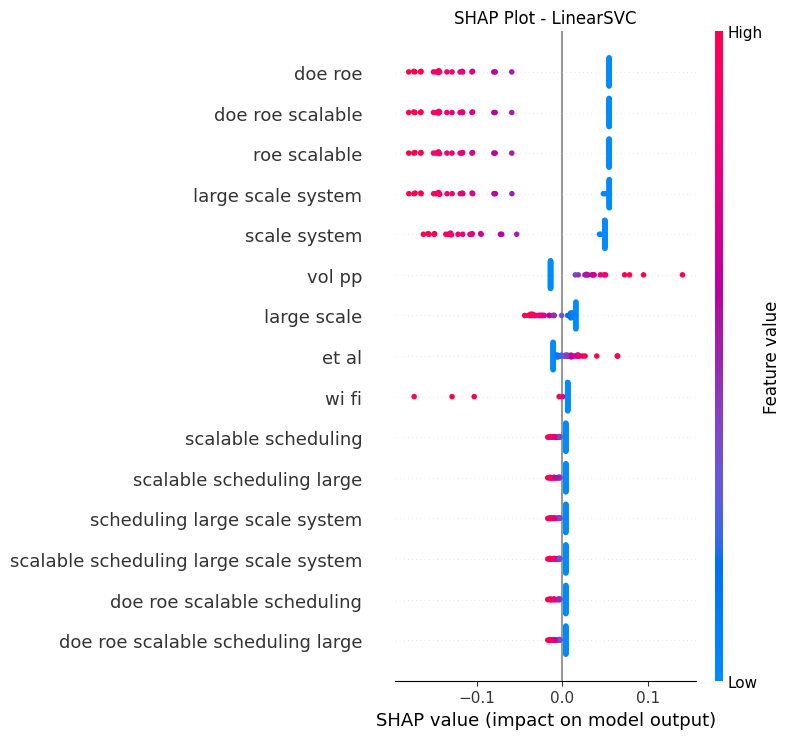

In [66]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names,
    show=False,
    max_display=15
)
plt.title("SHAP Plot - LinearSVC")
plt.tight_layout()
plt.show()